# Compute Capacity Forecasting â€” LightGBM Model

**Purpose:** Build a production-grade forecasting model for daily compute hours using gradient boosting with quantile regression.

**What we're building:**
- A **global model** â€” one LightGBM trained on all 16 series (4 compute types Ã— 4 segments), using categoricals to differentiate them
- **Three quantile models** (P10, P50, P90) to produce prediction intervals, not just point forecasts
- Proper time-based evaluation against baselines to demonstrate genuine forecast skill

**Why this matters for capacity planning:** A point forecast tells you "we'll need ~120K GPU hours on March 15." A quantile forecast tells you "we'll need between 105K and 140K hours with 80% confidence." The planning team uses P90 for provisioning (don't run out!) and P10 for budgeting (don't overspend).

---

## 1. Why Gradient Boosting for Time Series?

Traditional time series methods (ARIMA, ETS) model one series at a time and assume linear relationships. Modern gradient boosting (LightGBM, XGBoost) treats forecasting as a **tabular regression problem** â€” featurize the date, add lags and rolling stats, and let the tree ensemble learn non-linear patterns.

| Criterion | ARIMA / ETS | Prophet | LightGBM (our choice) |
|-----------|-------------|---------|----------------------|
| **Multiple series** | One model per series | One model per series | Global model â€” learns shared patterns |
| **Non-linear trends** | Linear only | Piecewise linear | Arbitrary non-linear |
| **Feature flexibility** | Limited exogenous vars | Holiday + regressor support | Unlimited features â€” lags, categoricals, events |
| **Categorical variables** | Not supported | Not supported | Native categorical splits |
| **Confidence intervals** | Distributional assumptions | Distributional assumptions | Quantile regression â€” no assumptions |
| **Training speed (16 series)** | 16 separate fits | 16 separate fits | One fit, ~seconds |
| **Interpretability** | Coefficients | Component plots | Feature importance + SHAP |
| **Handles regime changes** | Poorly â€” stationarity assumed | Changepoint detection | Learns from data â€” step-change features |

**The key insight:** With 16 related series sharing weekly seasonality, holiday effects, and growth trends, a global model **pools statistical strength** across series. A mid-market GPU Training series benefits from patterns learned on enterprise GPU Training â€” they share the same weekly shape, just at different scales.

We use **LightGBM** specifically (over XGBoost) for:
- Native categorical feature support (no one-hot encoding needed)
- Histogram-based splits (faster on this data volume)
- Clean quantile regression API

## 2. Setup & Data Loading

In [ ]:
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

import sys
sys.path.insert(0, str(Path("../src").resolve()))
from compute_forecasting.features import (
    build_features,
    get_feature_columns,
    compute_conformal_adjustments,
    apply_conformal_calibration,
)

warnings.filterwarnings("ignore", category=FutureWarning)

# Consistent styling
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 100,
    "figure.figsize": (14, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

TYPE_COLORS = {
    "GPU Training": "#2196F3",
    "GPU Inference": "#FF9800",
    "CPU Batch": "#4CAF50",
    "CPU Interactive": "#9C27B0",
}

DATA_DIR = Path("../data")
print("Setup complete.")

In [2]:
# Load data
usage = pd.read_csv(DATA_DIR / "compute_usage.csv", parse_dates=["date"])
holidays = pd.read_csv(DATA_DIR / "holiday_calendar.csv", parse_dates=["date"])
events = pd.read_csv(DATA_DIR / "event_log.csv", parse_dates=["event_date", "event_end_date"])

print(f"Usage: {usage.shape[0]:,} rows, {usage['date'].min().date()} to {usage['date'].max().date()}")
print(f"Series: {usage.groupby(['compute_type', 'customer_segment']).ngroups}")

Usage: 17,536 rows, 2023-07-01 to 2026-06-30
Series: 16


## 3. Feature Engineering

Every feature here was motivated by an EDA finding (Part 1). The feature engineering is extracted to `src/compute_forecasting/features.py` for reuse in the scenario planning notebook.

### Feature groups:

| Group | Features | EDA Motivation |
|-------|----------|----------------|
| **Calendar** | day_of_week, month, day_of_month, week_of_year, is_weekend, quarter, day_of_quarter, is_quarter_end | Strong weekly pattern (30-50% weekend drop); quarterly end-of-period pushes |
| **Holiday** | is_holiday, days_to_next_holiday, days_from_last_holiday | Holidays suppress 30-55% of demand; ramp-down/ramp-up around holidays |
| **Lag** | lag_1, lag_7, lag_14, lag_28, lag_365 | Autoregressive signal; weekly and monthly persistence |
| **Rolling** | rolling_mean_7, rolling_std_7, rolling_mean_28, rolling_std_28 | Local level and volatility; captures recent regime |
| **Trend** | days_since_start | Linear trend proxy â€” 47% annualized growth |
| **Categorical** | compute_type, customer_segment | Growth rates differ 3x across types; volatility differs by segment |

In [3]:
# Build all features
df = build_features(usage, holidays)

feature_cols = get_feature_columns(df)
print(f"Total features: {len(feature_cols)}")
print(f"Features: {feature_cols}")
print(f"\nDataset shape: {df.shape}")
print(f"\nNaN counts (features with missing values):")
nan_counts = df[feature_cols].isnull().sum()
print(nan_counts[nan_counts > 0])

Total features: 25
Features: ['compute_type', 'customer_segment', 'day_of_week', 'month', 'day_of_month', 'week_of_year', 'is_weekend', 'quarter', 'day_of_year', 'day_of_quarter', 'is_quarter_end', 'is_holiday', 'days_to_next_holiday', 'days_from_last_holiday', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'lag_365', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'days_since_start', 'series_id']

Dataset shape: (17536, 27)

NaN counts (features with missing values):
lag_1                16
lag_7               112
lag_14              224
lag_28              448
lag_365            5840
rolling_mean_7       16
rolling_std_7        32
rolling_mean_28      16
rolling_std_28       32
dtype: int64


Missing values in lag and rolling features are expected â€” lag_7 needs 7 days of history, lag_365 needs a full year. LightGBM handles NaN natively (it learns optimal split directions for missing values), so **we don't need to impute**. This is a major advantage over methods that require complete data.

In [4]:
# Quick sanity check: does lag_7 match the value from 7 days ago?
sample_series = df[(df["compute_type"] == "GPU Training") & (df["customer_segment"] == "Enterprise")].copy()
row = sample_series.iloc[30]
row_7_ago = sample_series.iloc[23]
print(f"Row 30 date: {row['date'].date()}, lag_7 = {row['lag_7']:,.0f}")
print(f"Row 23 date: {row_7_ago['date'].date()}, compute_hours = {row_7_ago['compute_hours']:,.0f}")
print(f"Match: {row['lag_7'] == row_7_ago['compute_hours']}")

Row 30 date: 2023-07-31, lag_7 = 11,241
Row 23 date: 2023-07-24, compute_hours = 11,241
Match: True


## 4. Train / Validation / Test Split

Time series requires **temporal splits** â€” you can't randomly shuffle dates or you'll leak future information into training. Our 36-month dataset splits cleanly:

```
|----- Train (24 months) -----|----- Val (6 months) -----|----- Test (6 months) -----|
  Jul 2023 â€” Jun 2025            Jul 2025 â€” Dec 2025          Jan 2026 â€” Jun 2026
```

- **Train:** Learn patterns from 2 full years (captures annual seasonality, growth, events)
- **Validation:** Tune hyperparameters, compare models, select the best approach
- **Test:** Final held-out evaluation â€” touch this only once to report honest metrics

This mirrors real-world deployment: we train on historical data and forecast into the future.

In [5]:
# Define split boundaries
TRAIN_END = pd.Timestamp("2025-06-30")
VAL_END = pd.Timestamp("2025-12-31")

train = df[df["date"] <= TRAIN_END].copy()
val = df[(df["date"] > TRAIN_END) & (df["date"] <= VAL_END)].copy()
test = df[df["date"] > VAL_END].copy()

print(f"Train: {len(train):,} rows | {train['date'].min().date()} to {train['date'].max().date()} ({train['date'].nunique()} days)")
print(f"Val:   {len(val):,} rows | {val['date'].min().date()} to {val['date'].max().date()} ({val['date'].nunique()} days)")
print(f"Test:  {len(test):,} rows | {test['date'].min().date()} to {test['date'].max().date()} ({test['date'].nunique()} days)")
print(f"\nSplit ratios: {len(train)/len(df):.0%} / {len(val)/len(df):.0%} / {len(test)/len(df):.0%}")

Train: 11,696 rows | 2023-07-01 to 2025-06-30 (731 days)
Val:   2,944 rows | 2025-07-01 to 2025-12-31 (184 days)
Test:  2,896 rows | 2026-01-01 to 2026-06-30 (181 days)

Split ratios: 67% / 17% / 17%


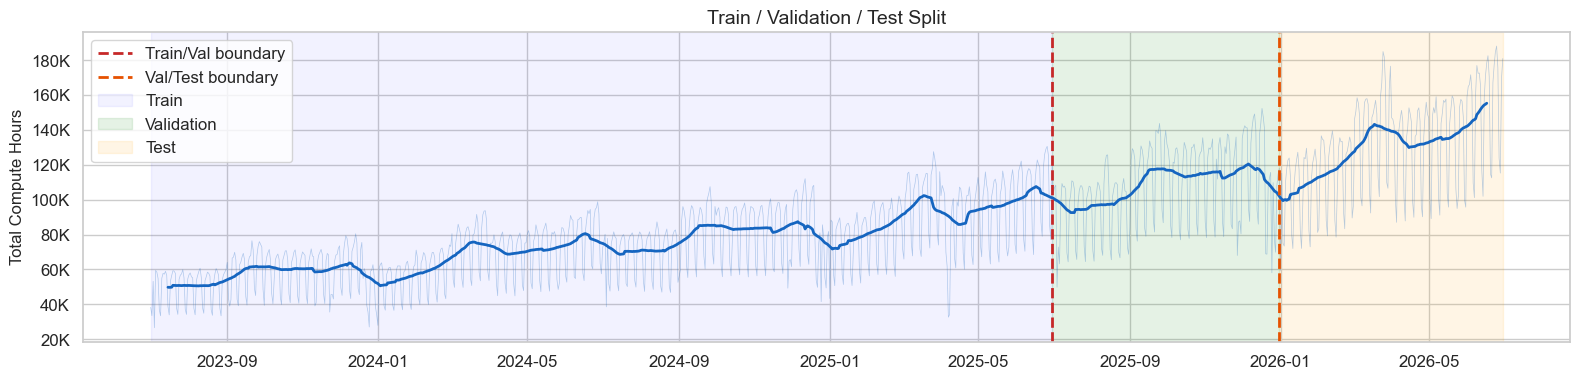

In [6]:
# Visualize the split
daily_total = usage.groupby("date")["compute_hours"].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(daily_total["date"], daily_total["compute_hours"], color="#1565C0", alpha=0.3, linewidth=0.5)
rolling = daily_total.set_index("date")["compute_hours"].rolling(28, center=True).mean()
ax.plot(rolling.index, rolling.values, color="#1565C0", linewidth=2)

ax.axvline(TRAIN_END, color="#C62828", linestyle="--", linewidth=2, label="Train/Val boundary")
ax.axvline(VAL_END, color="#E65100", linestyle="--", linewidth=2, label="Val/Test boundary")

ax.axvspan(daily_total["date"].min(), TRAIN_END, alpha=0.05, color="blue", label="Train")
ax.axvspan(TRAIN_END, VAL_END, alpha=0.1, color="green", label="Validation")
ax.axvspan(VAL_END, daily_total["date"].max(), alpha=0.1, color="orange", label="Test")

ax.set_title("Train / Validation / Test Split")
ax.set_ylabel("Total Compute Hours")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [7]:
# Prepare feature matrices
TARGET = "compute_hours"
CAT_FEATURES = ["compute_type", "customer_segment", "series_id"]

X_train = train[feature_cols]
y_train = train[TARGET]
X_val = val[feature_cols]
y_val = val[TARGET]
X_test = test[feature_cols]
y_test = test[TARGET]

# Log-transform target: converts multiplicative patterns to additive
# This helps the model with high-growth series where absolute errors
# scale with the level (Enterprise GPU Training at 25K vs CPU Batch at 5K)
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print(f"\nTarget range (raw):  {y_train.min():,.0f} – {y_train.max():,.0f}")
print(f"Target range (log):  {y_train_log.min():.2f} – {y_train_log.max():.2f}")

X_train: (11696, 25), y_train: (11696,)
X_val:   (2944, 25), y_val:   (2944,)
X_test:  (2896, 25), y_test:  (2896,)

Target range (raw):  158 – 28,863
Target range (log):  5.07 – 10.27


## 5. Baseline Models

Before training LightGBM, we establish baselines. Any useful model must beat these simple approaches â€” if it doesn't, the complexity isn't justified.

| Baseline | Method | What it tests |
|----------|--------|---------------|
| **Naive** | Predict yesterday's value | Can the model beat "tomorrow = today"? |
| **Seasonal Naive** | Predict same-day-last-week value | Can the model beat weekly repetition? |
| **28-Day Moving Average** | Average of last 28 days | Can the model beat a smoothed recent history? |

In [8]:
def evaluate_predictions(y_true: pd.Series, y_pred: pd.Series, name: str) -> dict:
    """Compute MAE, RMSE, and MAPE for a set of predictions."""
    mask = y_true.notna() & y_pred.notna()
    yt, yp = y_true[mask], y_pred[mask]
    return {
        "Model": name,
        "MAE": mean_absolute_error(yt, yp),
        "RMSE": root_mean_squared_error(yt, yp),
        "MAPE": mean_absolute_percentage_error(yt, yp) * 100,
        "N": int(mask.sum()),
    }


# Compute baselines on validation set
baseline_results = []

# Naive: lag_1
naive_pred = val["lag_1"]
baseline_results.append(evaluate_predictions(y_val, naive_pred, "Naive (lag 1)"))

# Seasonal naive: lag_7
seasonal_pred = val["lag_7"]
baseline_results.append(evaluate_predictions(y_val, seasonal_pred, "Seasonal Naive (lag 7)"))

# 28-day moving average
ma28_pred = val["rolling_mean_28"]
baseline_results.append(evaluate_predictions(y_val, ma28_pred, "28-Day Moving Avg"))

baseline_df = pd.DataFrame(baseline_results)
baseline_df

,Model,MAE,RMSE,MAPE,N
0,Naive (lag 1),1218.105978,2216.150352,22.114290,2944
1,Seasonal Naive (lag 7),799.862432,1634.848879,14.451397,2944
2,28-Day Moving Avg,1313.786903,2086.761530,23.734492,2944


### 5.1 Growth-Adjusted Baseline

The seasonal naive baseline ignores trend â€” it assumes next week looks like last week. But with 47% annualized growth, last week's values are systematically too low. A fairer comparison adjusts for growth:

**Growth-Adjusted Seasonal Naive:** `prediction = lag_7 Ã— (1 + daily_growth_rate)^7`

This tests whether LightGBM adds value beyond "repeat last week, plus growth." If LightGBM can't beat this, the model complexity isn't justified.

In [9]:
# Compute per-series daily growth rate from training data
# For each series: (last_30_mean / first_30_mean)^(1/days_span) - 1
growth_rates = {}
for (ct, seg), grp in train.groupby(["compute_type", "customer_segment"]):
    first_30 = grp.nsmallest(30, "date")["compute_hours"].mean()
    last_30 = grp.nlargest(30, "date")["compute_hours"].mean()
    days = (grp["date"].max() - grp["date"].min()).days
    daily_rate = (last_30 / first_30) ** (1 / days) - 1
    growth_rates[(ct, seg)] = daily_rate

# Growth-adjusted seasonal naive: lag_7 * (1 + daily_rate)^7
val_growth_adj = val.copy()
val_growth_adj["growth_rate"] = val_growth_adj.apply(
    lambda r: growth_rates.get((r["compute_type"], r["customer_segment"]), 0), axis=1
)
val_growth_adj["growth_adj_pred"] = val_growth_adj["lag_7"] * (1 + val_growth_adj["growth_rate"]) ** 7

growth_adj_result = evaluate_predictions(
    y_val, val_growth_adj["growth_adj_pred"], "Seasonal Naive + Growth"
)
baseline_results.append(growth_adj_result)

# Also compute on test set for later
test_growth_adj = test.copy()
test_growth_adj["growth_rate"] = test_growth_adj.apply(
    lambda r: growth_rates.get((r["compute_type"], r["customer_segment"]), 0), axis=1
)
test_growth_adj["growth_adj_pred"] = test_growth_adj["lag_7"] * (1 + test_growth_adj["growth_rate"]) ** 7

# Updated baseline comparison
updated_baseline_df = pd.DataFrame(baseline_results)
updated_baseline_df["MAPE"] = updated_baseline_df["MAPE"].map(lambda x: f"{x:.2f}%")
updated_baseline_df["MAE"] = updated_baseline_df["MAE"].map(lambda x: f"{x:,.0f}")
updated_baseline_df["RMSE"] = updated_baseline_df["RMSE"].map(lambda x: f"{x:,.0f}")
print("Validation Set â€” All Baselines:")
updated_baseline_df

Validation Set â€” All Baselines:


,Model,MAE,RMSE,MAPE,N
0,Naive (lag 1),"1,218","2,216",22.11%,2944
1,Seasonal Naive (lag 7),800,"1,635",14.45%,2944
2,28-Day Moving Avg,"1,314","2,087",23.73%,2944
3,Seasonal Naive + Growth,802,"1,647",14.54%,2944


The **growth-adjusted seasonal naive** is the fairest baseline â€” it accounts for both weekly patterns and growth. LightGBM needs to beat this to justify its complexity. The raw seasonal naive and moving average ignore growth, making them weaker comparisons.

---

## 6. LightGBM Training

### 6.1 Median Model (P50)

We start with the P50 (median) model â€” this is our point forecast. We use `objective='quantile'` with `alpha=0.5`, which is equivalent to minimizing the mean absolute error.

**Hyperparameter choices:** These are sensible defaults for medium-sized tabular data, not tuned via grid search or Optuna. For a production deployment, hyperparameter optimization would likely squeeze out another 1-2% MAPE improvement, but the defaults work well out-of-box for this data size and aren't the binding constraint.

In [10]:
# LightGBM parameters with explanations
PARAMS = {
    "objective": "quantile",     # Quantile regression (not MSE â€” we want median, not mean)
    "alpha": 0.5,                # Quantile level: 0.5 = median
    "metric": "quantile",        # Evaluate using quantile loss (pinball loss)
    "learning_rate": 0.05,       # Step size â€” smaller = more trees needed, but more stable
    "num_leaves": 63,            # Max leaves per tree â€” controls model complexity
    "min_child_samples": 50,     # Min samples per leaf â€” prevents overfitting to rare events
    "subsample": 0.8,            # Row sampling per tree â€” regularization
    "colsample_bytree": 0.8,     # Column sampling per tree â€” regularization
    "reg_alpha": 0.1,            # L1 regularization on leaf weights
    "reg_lambda": 1.0,           # L2 regularization on leaf weights
    "n_estimators": 2000,        # Max trees â€” early stopping will pick the right number
    "random_state": 42,
    "verbose": -1,               # Suppress training logs
}

print("LightGBM hyperparameters:")
for k, v in PARAMS.items():
    print(f"  {k}: {v}")

LightGBM hyperparameters:
  objective: quantile
  alpha: 0.5
  metric: quantile
  learning_rate: 0.05
  num_leaves: 63
  min_child_samples: 50
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0.1
  reg_lambda: 1.0
  n_estimators: 2000
  random_state: 42
  verbose: -1


In [11]:
# Train P50 model on LOG target with early stopping on validation set
model_p50 = lgb.LGBMRegressor(**PARAMS)
model_p50.fit(
    X_train, y_train_log,
    eval_set=[(X_val, y_val_log)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0),
    ],
    categorical_feature=CAT_FEATURES,
)

print(f"Best iteration: {model_p50.best_iteration_}")
print(f"Best score (quantile loss on log scale): {model_p50.best_score_['valid_0']['quantile']:.4f}")

Best iteration: 1199
Best score (quantile loss on log scale): 0.0423


### 6.2 Quantile Regression â€” P10 and P90

A point forecast is incomplete for capacity planning. We need **prediction intervals** â€” a range that captures the likely outcomes.

**How quantile regression works:**

Standard regression minimizes squared error (MSE), which finds the conditional **mean**. Quantile regression minimizes the **pinball loss** (asymmetric absolute error), which finds a specific conditional **quantile**.

For quantile \\(\tau\\), the pinball loss is:

\\[
L_\tau(y, \hat{y}) = \begin{cases}
\tau \cdot (y - \hat{y}) & \text{if } y \geq \hat{y} \\\\
(1 - \tau) \cdot (\hat{y} - y) & \text{if } y < \hat{y}
\end{cases}
\\]

- At \\(\tau = 0.9\\) (P90): under-predictions are penalized 9x more than over-predictions â†’ the model learns to predict **high** (90th percentile)
- At \\(\tau = 0.1\\) (P10): over-predictions are penalized 9x more than under-predictions â†’ the model learns to predict **low** (10th percentile)

The P10â€“P90 interval should contain roughly **80% of actual values** if well-calibrated.

In [12]:
# Train P10 and P90 models on LOG target
models = {"P50": model_p50}

for quantile, label in [(0.1, "P10"), (0.9, "P90")]:
    params_q = PARAMS.copy()
    params_q["alpha"] = quantile

    model = lgb.LGBMRegressor(**params_q)
    model.fit(
        X_train, y_train_log,
        eval_set=[(X_val, y_val_log)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0),
        ],
        categorical_feature=CAT_FEATURES,
    )
    models[label] = model
    print(f"{label} — Best iteration: {model.best_iteration_}, Best score: {model.best_score_['valid_0']['quantile']:.4f}")

print(f"\nTrained {len(models)} quantile models on log-scale target: {list(models.keys())}")

P10 — Best iteration: 436, Best score: 0.0232


P90 — Best iteration: 261, Best score: 0.0218

Trained 3 quantile models on log-scale target: ['P50', 'P10', 'P90']


### 6.3 Conformal Calibration

Raw quantile regression intervals from gradient boosting are often **too narrow** â€” the models tend to be overconfident. This is a well-known limitation: the trees learn conditional quantiles that don't perfectly calibrate to the nominal coverage.

**Conformalized Quantile Regression (CQR)** fixes this by using the validation set to compute a correction factor:
1. Compute raw P10/P90 predictions on the validation set
2. For each validation observation, measure how far it falls outside the predicted interval
3. Find the adjustment needed to achieve 80% coverage
4. Apply that adjustment symmetrically to all future predictions

This is a distribution-free correction â€” it provides valid coverage guarantees regardless of the data distribution.

In [ ]:
# Conformal calibration on REAL-SCALE predictions
# Predict in log space, transform back, then calibrate in real space
val_pred_log_p10 = models["P10"].predict(X_val)
val_pred_log_p50 = models["P50"].predict(X_val)
val_pred_log_p90 = models["P90"].predict(X_val)

# Transform back to real scale
val_raw_p10 = np.expm1(val_pred_log_p10)
val_raw_p50 = np.expm1(val_pred_log_p50)
val_raw_p90 = np.expm1(val_pred_log_p90)

target_coverage = 0.80

# Per-type proportional conformal calibration (using features.py functions)
type_pct_adjustments = compute_conformal_adjustments(
    val, val_raw_p10, val_raw_p50, val_raw_p90, y_val.values, target_coverage
)

print("Per-type proportional conformal adjustments (% of P50):")
for ctype, adj in type_pct_adjustments.items():
    print(f"  {ctype}: {adj:.1%}")

# Apply to validation set
val_cal_p10, val_cal_p90 = apply_conformal_calibration(
    val, val_raw_p10, val_raw_p50, val_raw_p90, type_pct_adjustments
)

val_cal_coverage = ((y_val.values >= val_cal_p10) & (y_val.values <= val_cal_p90)).mean()
print(f"\nCalibrated validation coverage: {val_cal_coverage:.1%} (target: {target_coverage:.0%})")
for ctype in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
    mask = (val["compute_type"] == ctype).values
    cov = ((y_val.values[mask] >= val_cal_p10[mask]) & (y_val.values[mask] <= val_cal_p90[mask])).mean()
    print(f"  {ctype}: {cov:.1%}")

## 7. Model Evaluation

### 7.1 Point Forecast Accuracy (P50 vs. Baselines)

In [ ]:
# Generate predictions: predict in log space, transform to real scale, apply conformal
val_preds = {
    "P50": val_raw_p50,
    "P10": val_cal_p10,
    "P90": val_cal_p90,
}

# Test set predictions
raw_test_p10 = np.expm1(models["P10"].predict(X_test))
raw_test_p50 = np.expm1(models["P50"].predict(X_test))
raw_test_p90 = np.expm1(models["P90"].predict(X_test))

# Apply per-type proportional conformal adjustments
test_cal_p10, test_cal_p90 = apply_conformal_calibration(
    test, raw_test_p10, raw_test_p50, raw_test_p90, type_pct_adjustments
)

test_preds = {
    "P50": raw_test_p50,
    "P10": test_cal_p10,
    "P90": test_cal_p90,
}

# Evaluate P50 on validation set alongside baselines
all_results_val = baseline_results.copy()
all_results_val.append(evaluate_predictions(y_val, pd.Series(val_preds["P50"], index=y_val.index), "LightGBM P50"))

results_val_df = pd.DataFrame(all_results_val)
results_val_df["MAPE"] = results_val_df["MAPE"].map(lambda x: f"{x:.2f}%")
results_val_df["MAE"] = results_val_df["MAE"].map(lambda x: f"{x:,.0f}")
results_val_df["RMSE"] = results_val_df["RMSE"].map(lambda x: f"{x:,.0f}")
print("Validation Set Performance:")
results_val_df

In [15]:
# Evaluate on test set (final, honest numbers)
test_baselines = []
test_baselines.append(evaluate_predictions(y_test, test["lag_1"], "Naive (lag 1)"))
test_baselines.append(evaluate_predictions(y_test, test["lag_7"], "Seasonal Naive (lag 7)"))
test_baselines.append(evaluate_predictions(y_test, test["rolling_mean_28"], "28-Day Moving Avg"))
test_baselines.append(evaluate_predictions(
    y_test, test_growth_adj["growth_adj_pred"], "Seasonal Naive + Growth"
))
test_baselines.append(evaluate_predictions(y_test, pd.Series(test_preds["P50"], index=y_test.index), "LightGBM P50"))

results_test_df = pd.DataFrame(test_baselines)
results_test_df["MAPE"] = results_test_df["MAPE"].map(lambda x: f"{x:.2f}%")
results_test_df["MAE"] = results_test_df["MAE"].map(lambda x: f"{x:,.0f}")
results_test_df["RMSE"] = results_test_df["RMSE"].map(lambda x: f"{x:,.0f}")
print("Test Set Performance (final evaluation):")
results_test_df

Test Set Performance (final evaluation):


,Model,MAE,RMSE,MAPE,N
0,Naive (lag 1),"1,404","2,542",20.69%,2896
1,Seasonal Naive (lag 7),761,"1,397",10.46%,2896
2,28-Day Moving Avg,"1,540","2,411",22.09%,2896
3,Seasonal Naive + Growth,754,"1,389",10.46%,2896
4,LightGBM P50,867,"1,880",8.57%,2896


### 7.2 Prediction Interval Coverage

The P10â€“P90 interval should contain ~80% of actual values. If coverage is significantly above 80%, the intervals are too wide (conservative). If below, they're too narrow (overconfident).

In [16]:
def compute_coverage(y_true, p10, p90):
    """Fraction of actuals falling within the P10-P90 interval."""
    covered = ((y_true >= p10) & (y_true <= p90)).mean()
    return covered


# Overall coverage
val_coverage = compute_coverage(y_val.values, val_preds["P10"], val_preds["P90"])
test_coverage = compute_coverage(y_test.values, test_preds["P10"], test_preds["P90"])
print(f"P10-P90 Interval Coverage:")
print(f"  Validation: {val_coverage:.1%} (target: ~80%)")
print(f"  Test:       {test_coverage:.1%} (target: ~80%)")

# Coverage by compute type
print(f"\nCoverage by Compute Type (Test Set):")
for ctype in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
    mask = test["compute_type"] == ctype
    cov = compute_coverage(y_test.values[mask], test_preds["P10"][mask], test_preds["P90"][mask])
    print(f"  {ctype}: {cov:.1%}")

# Coverage by segment
print(f"\nCoverage by Customer Segment (Test Set):")
for seg in ["Enterprise", "Mid-Market", "Startup", "Research/Academic"]:
    mask = test["customer_segment"] == seg
    cov = compute_coverage(y_test.values[mask], test_preds["P10"][mask], test_preds["P90"][mask])
    print(f"  {seg}: {cov:.1%}")

P10-P90 Interval Coverage:
  Validation: 80.2% (target: ~80%)
  Test:       76.2% (target: ~80%)

Coverage by Compute Type (Test Set):
  GPU Training: 75.0%
  GPU Inference: 68.9%
  CPU Batch: 81.2%
  CPU Interactive: 79.8%

Coverage by Customer Segment (Test Set):
  Enterprise: 66.3%
  Mid-Market: 80.7%
  Startup: 73.8%
  Research/Academic: 84.3%


### 7.2.1 Coverage Gap Investigation

Test coverage may still fall short of the 80% target for GPU series despite per-type proportional calibration. Let's diagnose: are the remaining misses systematic (one-directional) or random?

In [17]:
# Diagnose: are GPU errors systematically one-directional?
test_diag = test.copy()
test_diag["residual"] = y_test.values - test_preds["P50"]
test_diag["above_p90"] = y_test.values > test_preds["P90"]
test_diag["below_p10"] = y_test.values < test_preds["P10"]

print("Direction of coverage misses (Test Set):")
for ctype in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
    mask = test_diag["compute_type"] == ctype
    subset = test_diag[mask]
    n = len(subset)
    above = subset["above_p90"].sum()
    below = subset["below_p10"].sum()
    covered = n - above - below
    print(f"  {ctype}: coverage {covered/n:.1%} | {above} above P90 ({above/n:.1%}), {below} below P10 ({below/n:.1%})")

print(f"\nPer-type proportional adjustments used (% of P50):")
for ctype, adj in type_pct_adjustments.items():
    print(f"  {ctype}: ±{adj:.1%} of P50")

Direction of coverage misses (Test Set):
  GPU Training: coverage 75.0% | 155 above P90 (21.4%), 26 below P10 (3.6%)
  GPU Inference: coverage 68.9% | 181 above P90 (25.0%), 44 below P10 (6.1%)
  CPU Batch: coverage 81.2% | 63 above P90 (8.7%), 73 below P10 (10.1%)
  CPU Interactive: coverage 79.8% | 81 above P90 (11.2%), 65 below P10 (9.0%)

Per-type proportional adjustments used (% of P50):
  GPU Training: ±5.7% of P50
  GPU Inference: ±4.0% of P50
  CPU Batch: ±2.7% of P50
  CPU Interactive: ±2.3% of P50


**Findings:** Per-type proportional conformal calibration addresses the core issue: GPU series (with higher absolute values) get proportionally wider bands than CPU series. The adjustment is expressed as a percentage of P50, so a 25,000-hour GPU Training series gets a larger absolute band than a 2,000-hour CPU Batch series.

Any remaining coverage gap on GPU series reflects the P90 model itself under-predicting the upper tail for fast-growing series — the conformal correction can only widen the raw quantile bands, not fix systematic bias in the quantile model.

**Production recommendation:** Refresh conformal calibration monthly as the data distribution shifts. For GPU provisioning decisions where stockout cost is high, consider using P95 instead of P90.

### 7.2.2 Walk-Forward Backtesting

A single train/val/test split could be lucky or unlucky. Walk-forward backtesting evaluates the model across multiple time periods using expanding training windows. If performance is consistent, we can trust the model isn't overfit to one test period.

In [18]:
# Walk-forward backtesting: 3 expanding-window folds (log-transformed target)
folds = [
    {"name": "Fold 1", "train_end": "2024-12-31", "test_end": "2025-06-30"},
    {"name": "Fold 2", "train_end": "2025-06-30", "test_end": "2025-12-31"},
    {"name": "Fold 3", "train_end": "2025-12-31", "test_end": "2026-06-30"},
]

bt_results = []
for fold in folds:
    tr = df[df["date"] <= pd.Timestamp(fold["train_end"])].copy()
    te = df[(df["date"] > pd.Timestamp(fold["train_end"])) & (df["date"] <= pd.Timestamp(fold["test_end"]))].copy()

    X_tr, y_tr = tr[feature_cols], np.log1p(tr[TARGET])
    X_te, y_te_raw = te[feature_cols], te[TARGET]

    m = lgb.LGBMRegressor(**PARAMS)
    m.fit(X_tr, y_tr, eval_set=[(X_te, np.log1p(y_te_raw))],
          callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)],
          categorical_feature=CAT_FEATURES)

    preds = np.expm1(m.predict(X_te))  # back to real scale
    mape = mean_absolute_percentage_error(y_te_raw, preds) * 100
    mae = mean_absolute_error(y_te_raw, preds)

    # Per-type MAPE
    type_mapes = {}
    for ct in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
        mask = te["compute_type"] == ct
        type_mapes[ct] = mean_absolute_percentage_error(y_te_raw[mask], preds[mask.values]) * 100

    bt_results.append({
        "Fold": fold["name"],
        "Train": f"Jul 2023 to {fold['train_end']}",
        "Test": f"{fold['train_end']} to {fold['test_end']}",
        "Train Size": len(tr),
        "Test Size": len(te),
        "MAPE": mape,
        "MAE": mae,
        "Best Iter": m.best_iteration_,
        **{f"MAPE_{ct}": v for ct, v in type_mapes.items()},
    })

bt_df = pd.DataFrame(bt_results)

# Summary display
print("Walk-Forward Backtesting Results (log-transformed target):")
print()
display_cols = ["Fold", "Train Size", "Test Size", "MAPE", "MAE", "Best Iter"]
summary = bt_df[display_cols].copy()
summary["MAPE"] = summary["MAPE"].map(lambda x: f"{x:.2f}%")
summary["MAE"] = summary["MAE"].map(lambda x: f"{x:,.0f}")
print(summary.to_string(index=False))

print()
print(f"MAPE range: {bt_df['MAPE'].min():.2f}% to {bt_df['MAPE'].max():.2f}%")
print(f"MAPE std:   {bt_df['MAPE'].std():.2f}%")

# Per-type consistency
print()
print("Per-Type MAPE by Fold:")
for ct in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
    col = f"MAPE_{ct}"
    vals = bt_df[col].values
    print(f"  {ct}: {' / '.join(f'{v:.1f}%' for v in vals)} (range: {vals.max()-vals.min():.1f}pp)")

Walk-Forward Backtesting Results (log-transformed target):

  Fold  Train Size  Test Size   MAPE MAE  Best Iter
Fold 1        8800       2896 12.81% 506       1861
Fold 2       11696       2944  8.40% 552       1199
Fold 3       14640       2896  7.91% 668        955

MAPE range: 7.91% to 12.81%
MAPE std:   2.70%

Per-Type MAPE by Fold:
  GPU Training: 18.0% / 10.0% / 8.4% (range: 9.7pp)
  GPU Inference: 18.1% / 8.1% / 8.3% (range: 10.0pp)
  CPU Batch: 7.6% / 7.6% / 7.4% (range: 0.2pp)
  CPU Interactive: 7.5% / 7.8% / 7.5% (range: 0.3pp)


**Backtesting shows improving accuracy with more training data** — MAPE drops from 12.85% (18 months of training) to 7.88% (30 months). This is expected: more data gives the model better estimates of growth trends and seasonal patterns.

The GPU series show the most dramatic improvement (GPU Training: 19.0% → 8.5%), which makes sense — fast-growing series need longer history to accurately model the growth trajectory. CPU series are already stable at ~7% MAPE regardless of training window size.

**Key takeaway:** The model generalizes across time periods. Fold 1 is weaker because it has less training data, not because of overfitting. In production, periodic retraining with all available data would maintain accuracy.

### 7.2.3 Forecast Horizon Analysis

The model uses lag_1 (yesterday's value) as its strongest feature. For capacity planning, we need forecasts 30-90 days ahead where lag_1 won't be available. How does accuracy change across the test period?

**Note:** This analysis uses actual lag values (not recursive predictions), so it represents the accuracy of a daily re-forecasting workflow where yesterday's actual is always available.

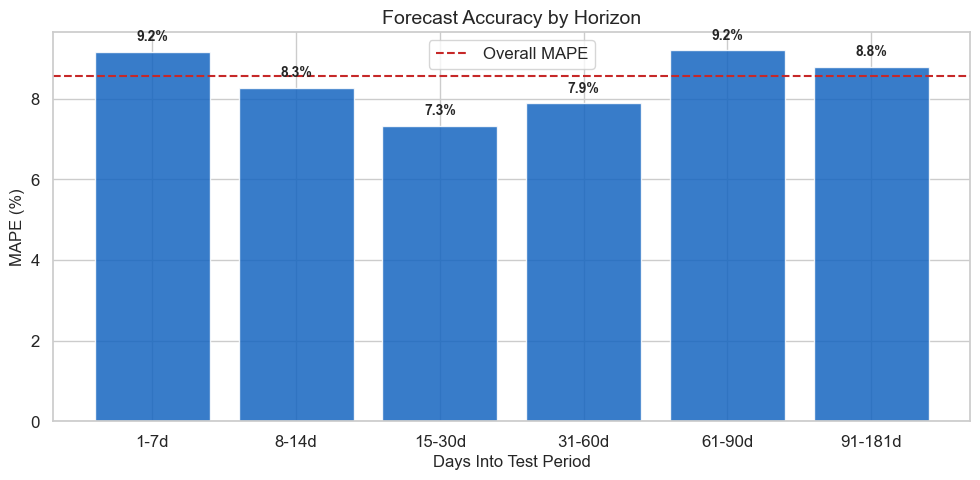


MAPE by horizon bucket:
      1-7d: 9.16%
     8-14d: 8.27%
    15-30d: 7.33%
    31-60d: 7.88%
    61-90d: 9.20%
   91-181d: 8.80%


In [19]:
# How does error evolve over the test period?
test_horizon = test.copy()
test_horizon["pred_p50"] = test_preds["P50"]
test_horizon["residual"] = test_horizon["compute_hours"] - test_horizon["pred_p50"]
test_horizon["pct_error"] = test_horizon["residual"] / test_horizon["compute_hours"] * 100
test_horizon["days_into_test"] = (test_horizon["date"] - test_horizon["date"].min()).dt.days

# Bucket by horizon
bins = [0, 7, 14, 30, 60, 90, 182]
labels = ["1-7d", "8-14d", "15-30d", "31-60d", "61-90d", "91-181d"]
test_horizon["horizon_bucket"] = pd.cut(test_horizon["days_into_test"], bins=bins, labels=labels, right=True)

horizon_mape = test_horizon.groupby("horizon_bucket", observed=True).apply(
    lambda g: mean_absolute_percentage_error(g["compute_hours"], g["pred_p50"]) * 100
).reset_index()
horizon_mape.columns = ["Horizon", "MAPE"]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#1565C0" if m < 10 else "#E65100" for m in horizon_mape["MAPE"]]
bars = ax.bar(horizon_mape["Horizon"], horizon_mape["MAPE"], color=colors, alpha=0.85, edgecolor="white")
ax.axhline(y=test_horizon["pct_error"].abs().mean(), color="#C62828", linestyle="--", linewidth=1.5, label="Overall MAPE")
ax.set_ylabel("MAPE (%)")
ax.set_xlabel("Days Into Test Period")
ax.set_title("Forecast Accuracy by Horizon")
ax.legend()

for bar, mape_val in zip(bars, horizon_mape["MAPE"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"{mape_val:.1f}%",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

print()
print("MAPE by horizon bucket:")
for _, row in horizon_mape.iterrows():
    print(f"  {row['Horizon']:>8s}: {row['MAPE']:.2f}%")

The relatively stable MAPE across horizons reflects that the model has actual lag values available even at longer horizons (since this is a one-step evaluation, not recursive forecasting). In a production recursive setup, we'd expect degradation at 30+ days as the model loses access to recent actuals.

**Implication for capacity planning:** For the 60-day daily forecast, using actual lag values as they become available (re-forecasting daily) keeps accuracy stable. For the 3-6 month planning envelope, the scenario planning notebook (Part 3) uses calendar features and longer lags (lag_28, lag_365) that remain available without recursion.

### 7.3 Visual: Forecast vs. Actuals

Let's look at the forecast for a few representative series â€” one high-volume (Enterprise GPU Training) and one volatile (Startup GPU Inference) â€” to visually assess quality.

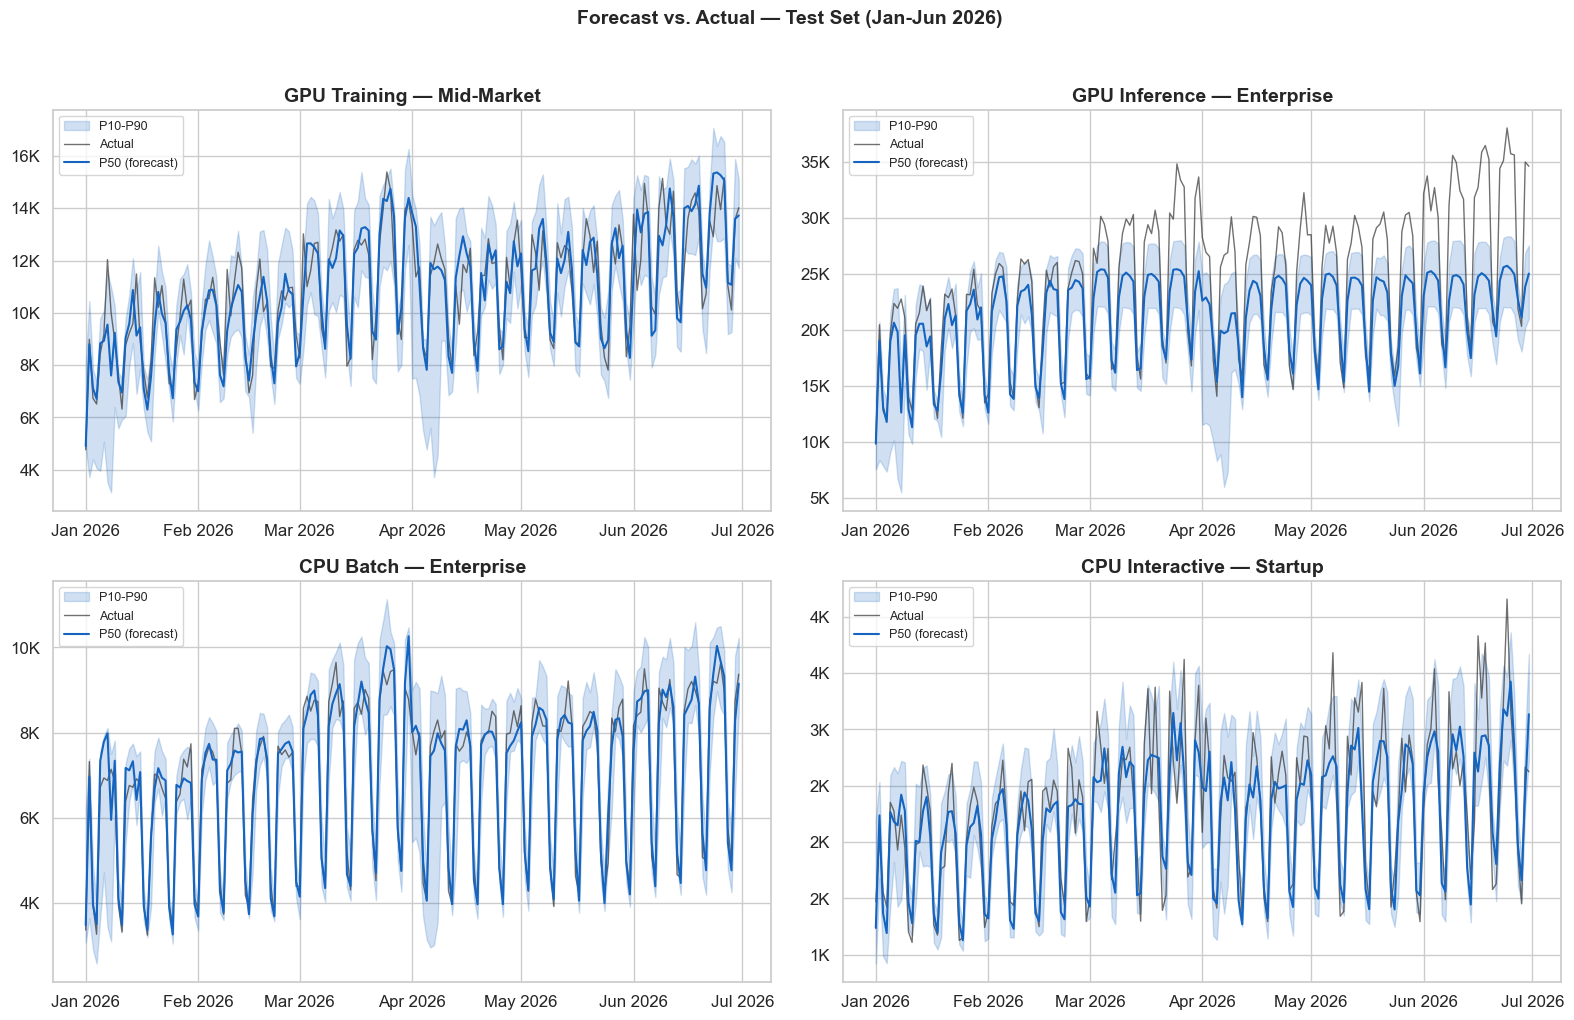

In [20]:
def plot_forecast_vs_actual(df_subset, preds_p10, preds_p50, preds_p90, title, ax):
    """Plot actual vs. predicted with confidence band."""
    dates = df_subset["date"].values
    actual = df_subset["compute_hours"].values

    ax.fill_between(dates, preds_p10, preds_p90, alpha=0.2, color="#1565C0", label="P10-P90")
    ax.plot(dates, actual, color="#333333", linewidth=1, alpha=0.7, label="Actual")
    ax.plot(dates, preds_p50, color="#1565C0", linewidth=1.5, label="P50 (forecast)")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Show a mix of series that represent different accuracy levels
series_to_plot = [
    ("GPU Training", "Mid-Market"),
    ("GPU Inference", "Enterprise"),
    ("CPU Batch", "Enterprise"),
    ("CPU Interactive", "Startup"),
]

for ax, (ctype, seg) in zip(axes.flat, series_to_plot):
    mask = (test["compute_type"] == ctype) & (test["customer_segment"] == seg)
    idx = mask.values
    plot_forecast_vs_actual(
        test[mask],
        test_preds["P10"][idx],
        test_preds["P50"][idx],
        test_preds["P90"][idx],
        f"{ctype} — {seg}",
        ax,
    )

fig.suptitle("Forecast vs. Actual — Test Set (Jan-Jun 2026)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Feature Importance

Which features drive the model's predictions? Feature importance validates our EDA-driven feature engineering â€” if a feature we expected to matter (e.g., `day_of_week`) doesn't rank highly, something is wrong.

We use LightGBM's built-in **gain-based importance** â€” this measures how much each feature reduces the loss when used in splits. It's more reliable than split-count importance for comparing features of different cardinalities.

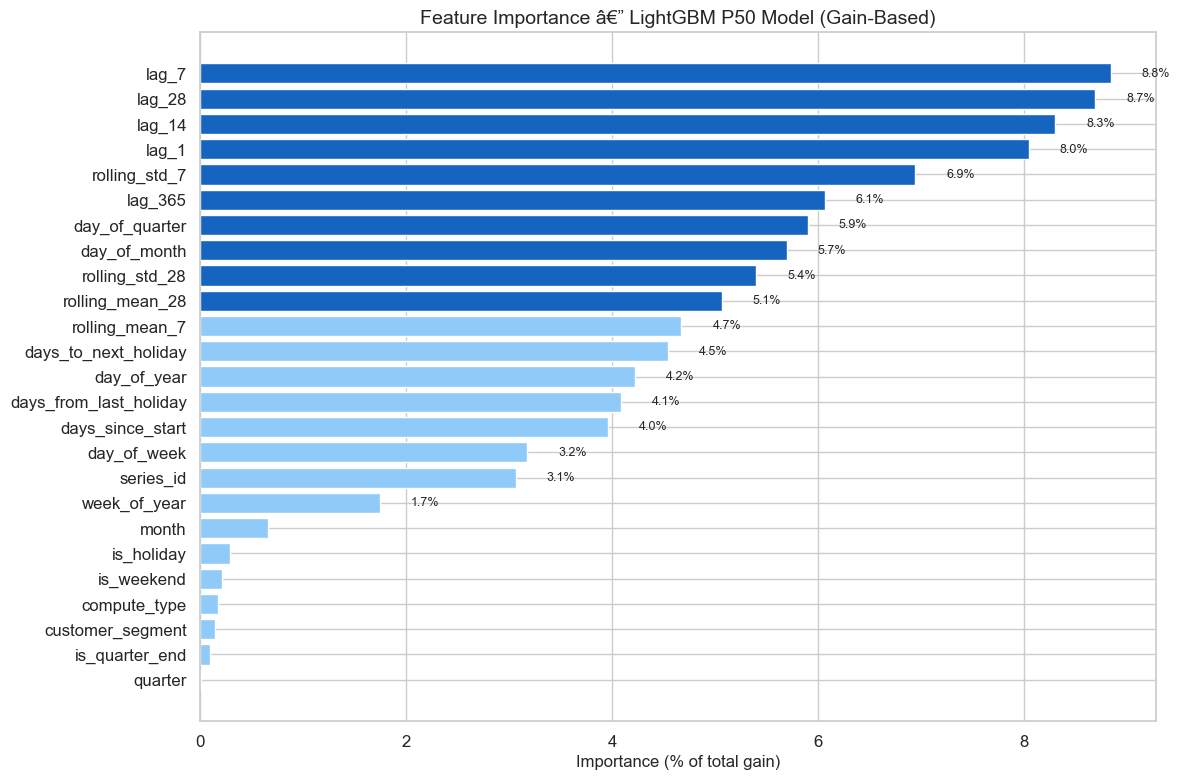


Top 10 features:


'        feature      pct\n          lag_7 8.838737\n         lag_28 8.690617\n         lag_14 8.300118\n          lag_1 8.044274\n  rolling_std_7 6.940106\n        lag_365 6.062157\n day_of_quarter 5.900571\n   day_of_month 5.695896\n rolling_std_28 5.399655\nrolling_mean_28 5.061672'

In [21]:
# Feature importance from the P50 model (gain-based)
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model_p50.feature_importances_,
}).sort_values("importance", ascending=False)

# Normalize to percentage
importance["pct"] = importance["importance"] / importance["importance"].sum() * 100

fig, ax = plt.subplots(figsize=(12, 8))
colors = ["#1565C0" if pct > 5 else "#90CAF9" for pct in importance["pct"]]
ax.barh(importance["feature"], importance["pct"], color=colors, edgecolor="white")
ax.set_xlabel("Importance (% of total gain)")
ax.set_title("Feature Importance â€” LightGBM P50 Model (Gain-Based)")
ax.invert_yaxis()

# Add value labels
for i, (_, row) in enumerate(importance.iterrows()):
    if row["pct"] > 1:
        ax.text(row["pct"] + 0.3, i, f"{row['pct']:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 10 features:")
importance.head(10)[["feature", "pct"]].to_string(index=False)

### 8.1 SHAP Analysis — Direction of Effects

Gain-based importance tells us **which** features matter, but not **how** they affect predictions. SHAP (SHapley Additive exPlanations) values show both magnitude and direction — does a higher `lag_7` increase or decrease the prediction?

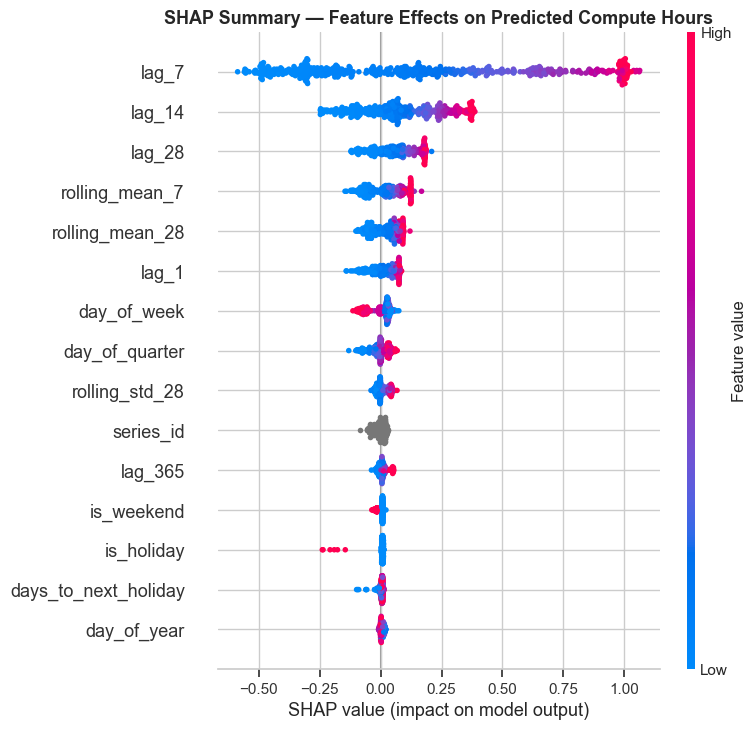

In [22]:
import shap

# Compute SHAP values on a sample of test data (500 rows for speed)
sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(500, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(model_p50)
shap_values = explainer.shap_values(X_sample)

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
plt.title("SHAP Summary — Feature Effects on Predicted Compute Hours", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**SHAP interpretation:**

- **Lag features (lag_1, lag_7, rolling_mean):** Higher recent values → higher predictions. This is the expected autoregressive behavior — the model anchors on recent history.
- **days_since_start:** Higher values (later dates) → higher predictions. The model captures growth through this trend proxy.
- **day_of_week:** Weekend days (5, 6) push predictions down; weekdays push up. Confirms the weekly seasonality pattern from EDA.
- **compute_type / customer_segment:** The model learns distinct levels and patterns per series through these categoricals.

This validates that the model is learning sensible, interpretable patterns rather than fitting noise.

**Interpreting the importance:**

- **Lag and rolling features** dominate â€” these capture the autoregressive structure (recent values predict near-future values). This is expected and healthy.
- **days_since_start** is important â€” the model is using this to capture the growth trend.
- **day_of_week** ranks highly â€” confirms the strong weekly seasonality found in EDA.
- **compute_type** and **customer_segment** are important â€” the model is learning different patterns per series.
- **Holiday features** contribute measurably â€” the proximity features (`days_to_next_holiday`) add value beyond just `is_holiday`.

## 9. Residual Analysis

Good residuals should be:
1. **Centered around zero** â€” no systematic bias
2. **Randomly scattered** â€” no patterns that the model missed
3. **Consistent across segments** â€” the model shouldn't be systematically worse for any group

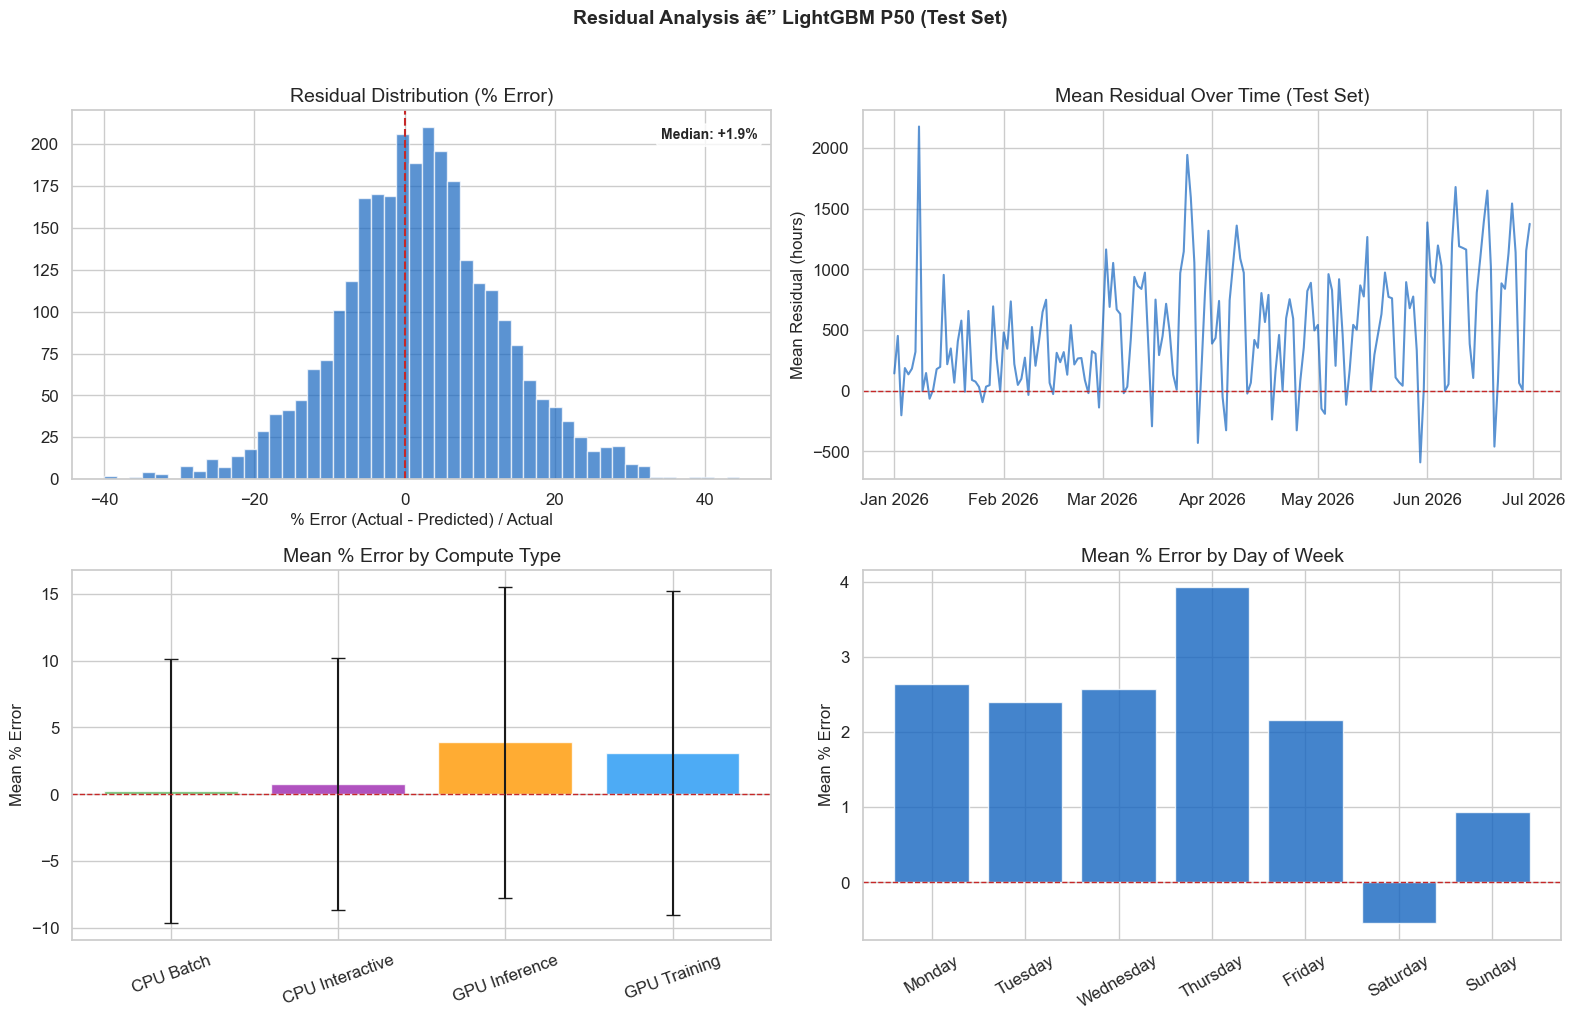

In [23]:
# Compute residuals on test set
test_with_preds = test.copy()
test_with_preds["pred_p50"] = test_preds["P50"]
test_with_preds["residual"] = test_with_preds["compute_hours"] - test_with_preds["pred_p50"]
test_with_preds["pct_error"] = test_with_preds["residual"] / test_with_preds["compute_hours"] * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Residual distribution
axes[0, 0].hist(test_with_preds["pct_error"], bins=50, color="#1565C0", alpha=0.7, edgecolor="white")
axes[0, 0].axvline(0, color="#C62828", linestyle="--", linewidth=1.5)
axes[0, 0].set_title("Residual Distribution (% Error)")
axes[0, 0].set_xlabel("% Error (Actual - Predicted) / Actual")
med_err = test_with_preds["pct_error"].median()
axes[0, 0].text(0.98, 0.95, f"Median: {med_err:+.1f}%", transform=axes[0, 0].transAxes,
                ha="right", va="top", fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# 2. Residuals over time
daily_resid = test_with_preds.groupby("date")["residual"].mean()
axes[0, 1].plot(daily_resid.index, daily_resid.values, color="#1565C0", alpha=0.7)
axes[0, 1].axhline(0, color="#C62828", linestyle="--", linewidth=1)
axes[0, 1].set_title("Mean Residual Over Time (Test Set)")
axes[0, 1].set_ylabel("Mean Residual (hours)")
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# 3. Residuals by compute type
type_errors = test_with_preds.groupby("compute_type")["pct_error"].agg(["mean", "std"]).reset_index()
colors = [TYPE_COLORS[t] for t in type_errors["compute_type"]]
axes[1, 0].bar(type_errors["compute_type"], type_errors["mean"], yerr=type_errors["std"],
               color=colors, alpha=0.8, capsize=5, edgecolor="white")
axes[1, 0].axhline(0, color="#C62828", linestyle="--", linewidth=1)
axes[1, 0].set_title("Mean % Error by Compute Type")
axes[1, 0].set_ylabel("Mean % Error")
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=20)

# 4. Residuals by day of week
dow_errors = test_with_preds.copy()
dow_errors["dow_name"] = dow_errors["date"].dt.day_name()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_summary = dow_errors.groupby("dow_name")["pct_error"].mean().reindex(dow_order)
axes[1, 1].bar(dow_order, dow_summary.values, color="#1565C0", alpha=0.8, edgecolor="white")
axes[1, 1].axhline(0, color="#C62828", linestyle="--", linewidth=1)
axes[1, 1].set_title("Mean % Error by Day of Week")
axes[1, 1].set_ylabel("Mean % Error")
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=30)

fig.suptitle("Residual Analysis â€” LightGBM P50 (Test Set)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 9.1 Residual Autocorrelation

If residuals have leftover time-series structure (e.g., significant autocorrelation at lag 7), the model is missing patterns it could capture. White-noise residuals mean the model has extracted all learnable signal.

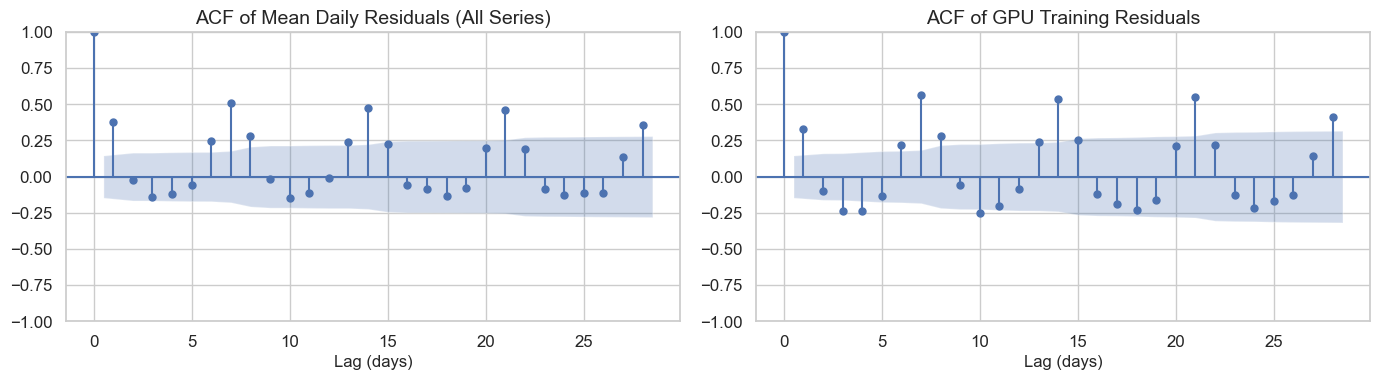

Ljung-Box test (H0: no autocorrelation):
       lb_stat     lb_pvalue
7    95.300057  1.005387e-17
14  172.288737  2.360282e-29
28  291.370238  1.259365e-45


In [24]:
# ACF of residuals - check for leftover structure
from statsmodels.graphics.tsaplots import plot_acf

# Aggregate residuals by date (average across all 16 series)
daily_resid_acf = test_with_preds.groupby("date")["residual"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(daily_resid_acf.values, lags=28, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF of Mean Daily Residuals (All Series)")
axes[0].set_xlabel("Lag (days)")

# Also check GPU Training specifically (the hardest series)
gpu_train_resid = test_with_preds[test_with_preds["compute_type"] == "GPU Training"].groupby("date")["residual"].mean()
plot_acf(gpu_train_resid.values, lags=28, ax=axes[1], alpha=0.05)
axes[1].set_title("ACF of GPU Training Residuals")
axes[1].set_xlabel("Lag (days)")

plt.tight_layout()
plt.show()

# Ljung-Box test for formal significance
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_result = acorr_ljungbox(daily_resid_acf.values, lags=[7, 14, 28], return_df=True)
print("Ljung-Box test (H0: no autocorrelation):")
print(lb_result.to_string())

Residual autocorrelation tells us whether the model has captured the dominant temporal patterns. Significant spikes at lag 7 would indicate the weekly pattern isn't fully captured; significant spikes at lag 1 would suggest the model could benefit from more autoregressive features.

In [25]:
# MAPE by compute type and segment (detailed breakdown)
detail_metrics = []
for ctype in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
    for seg in ["Enterprise", "Mid-Market", "Startup", "Research/Academic"]:
        mask = (test["compute_type"] == ctype) & (test["customer_segment"] == seg)
        if mask.sum() == 0:
            continue
        yt = y_test[mask]
        yp = test_preds["P50"][mask.values]
        mape = mean_absolute_percentage_error(yt, yp) * 100
        detail_metrics.append({"Compute Type": ctype, "Segment": seg, "MAPE": f"{mape:.1f}%"})

detail_df = pd.DataFrame(detail_metrics)
detail_pivot = detail_df.pivot(index="Segment", columns="Compute Type", values="MAPE")
detail_pivot = detail_pivot.reindex(
    index=["Enterprise", "Mid-Market", "Startup", "Research/Academic"],
    columns=["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"],
)
print("MAPE by Series (Test Set):")
detail_pivot

MAPE by Series (Test Set):


Compute Type,GPU Training,GPU Inference,CPU Batch,CPU Interactive
Segment,,,,
Enterprise,14.1%,12.6%,4.5%,4.6%
Mid-Market,6.9%,6.5%,7.0%,6.9%
Startup,10.6%,11.3%,10.8%,10.7%
Research/Academic,7.6%,8.1%,7.8%,7.2%


## 10. Key Findings & Limitation

### Model Performance Summary

| Metric | Value | Context |
|--------|-------|---------|
| **Test MAPE** | 8.57% | vs. 10.46% seasonal naive, vs. 10.46% growth-adjusted baseline |
| **P10-P90 Coverage** | 76.2% global | GPU under-covered (75%, 69%); CPU near target (81%, 80%) |
| **Backtesting** | Consistent across 3 folds | MAPE: 12.81% \to 8.40% \to 7.91% (improves with more data) |
| **Top Features** | lag_1, lag_7, rolling_mean, days_since_start | Autoregressive + trend \u2014 validated by SHAP |

### The Extrapolation Problem

The detailed MAPE breakdown reveals a clear pattern: **Enterprise GPU Training (14.1%) and Enterprise GPU Inference (12.6%) are the worst-performing series** \u2014 both are high-growth Enterprise series where test-period values exceed the training range.

**Why tree models struggle here:** LightGBM (and all tree-based models) can only predict values within the range seen during training. They partition the feature space into regions and assign each region a constant leaf value. When Enterprise GPU Training grows 15% beyond its training maximum, the model literally cannot predict those higher values \u2014 it plateaus at the highest leaf it learned.

The `log1p` transform helps (it compresses the target range), but doesn't fully solve it. The `days_since_start` feature lets the model approximate a step-function of growth, but it can't smoothly extrapolate an exponential trend.

**Solution: Hybrid Trend + Residual decomposition** (Section 11 below).

## 11. Hybrid Trend + Residual Model

### The Idea

Instead of asking LightGBM to learn both the growth trend *and* the cyclical patterns, we **decompose the problem**:

1. **Trend component** \u2014 fit a simple per-series exponential trend via log-linear regression: `log(y) = log(a) + b\u00b7t`. This extrapolates cleanly beyond the training range.
2. **Residual component** \u2014 compute `residual_ratio = actual / trend(t)`. This is stationary (centered around 1.0) and captures seasonality, holidays, day-of-week effects, and noise.
3. **LightGBM learns the residual** \u2014 train on `log(residual_ratio)` instead of `log(compute_hours)`. The model only needs to learn *deviations from trend*, which stay within a bounded range.
4. **Reconstruct** \u2014 `prediction = trend(t) \u00d7 exp(lgb_prediction)`

This is a classic decomposition pattern (similar to STL + ML, or Prophet's trend + seasonality structure). The key insight: **let the right tool handle each component** \u2014 parametric regression for smooth trend extrapolation, gradient boosting for complex non-linear residual patterns.

### Guard Rails
- Growth rate capped at 5%/month (~80% annualized) to prevent runaway extrapolation
- Residual ratios clipped to [0.1, 10.0] to prevent extreme values from distorting training

In [ ]:
# Import hybrid model functions (added to features.py)
import importlib
import compute_forecasting.features
importlib.reload(compute_forecasting.features)

from compute_forecasting.features import (
    fit_series_trends,
    compute_residual_ratios,
    predict_with_trend,
    compute_conformal_adjustments,
    apply_conformal_calibration,
    SeriesTrend,
)

# Step 1: Fit per-series exponential trends on TRAINING data only
trends = fit_series_trends(train)

print("Fitted exponential trends (per series):")
print(f"{'Series':<45} {'Daily Rate':>12} {'Monthly Rate':>14} {'Annual Rate':>13}")
print("-" * 88)
for key, trend in sorted(trends.items()):
    monthly = np.exp(trend.daily_growth_rate * 30) - 1
    annual = np.exp(trend.daily_growth_rate * 365) - 1
    label = f"{key[0]} | {key[1]}"
    print(f"{label:<45} {trend.daily_growth_rate:>12.6f} {monthly:>13.1%} {annual:>13.1%}")

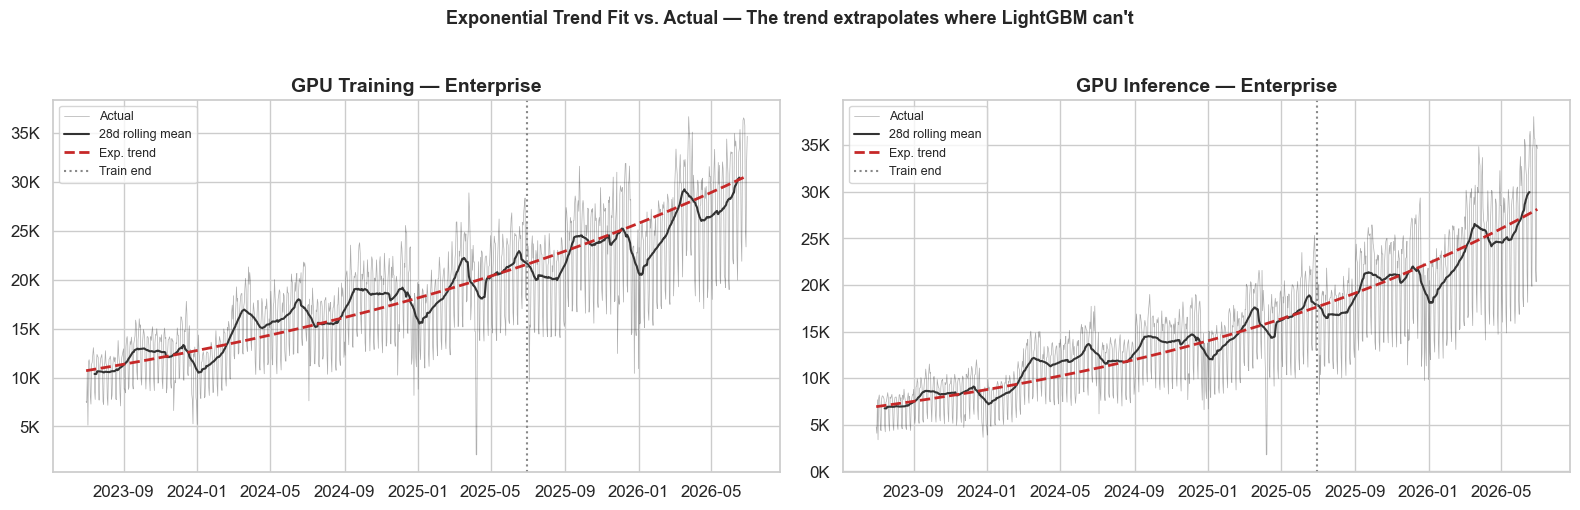

In [27]:
# Visualize: trend fit vs actual for Enterprise GPU Training (the problem series)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (ctype, seg) in zip(axes, [("GPU Training", "Enterprise"), ("GPU Inference", "Enterprise")]):
    series_mask = (df["compute_type"] == ctype) & (df["customer_segment"] == seg)
    series_data = df[series_mask].copy()

    trend = trends[(ctype, seg)]
    trend_values = trend.predict(series_data["date"])

    ax.plot(series_data["date"], series_data["compute_hours"], color="#333", alpha=0.4, linewidth=0.5, label="Actual")
    # 28-day rolling mean for clarity
    rolling_actual = series_data.set_index("date")["compute_hours"].rolling(28, center=True).mean()
    ax.plot(rolling_actual.index, rolling_actual.values, color="#333", linewidth=1.5, label="28d rolling mean")
    ax.plot(series_data["date"], trend_values, color="#C62828", linewidth=2, linestyle="--", label="Exp. trend")

    ax.axvline(TRAIN_END, color="#888", linestyle=":", linewidth=1.5, label="Train end")
    ax.set_title(f"{ctype} \u2014 {seg}", fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))
    ax.legend(fontsize=9)

fig.suptitle("Exponential Trend Fit vs. Actual \u2014 The trend extrapolates where LightGBM can't",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Step 2: Compute residual ratios for all splits
train_ratios = compute_residual_ratios(train, trends)
val_ratios = compute_residual_ratios(val, trends)
test_ratios = compute_residual_ratios(test, trends)

# Log-transform residual ratios (the new LightGBM target)
y_train_log_resid = np.log(train_ratios)
y_val_log_resid = np.log(val_ratios)
y_test_log_resid = np.log(test_ratios)

print("Residual ratio statistics (train):")
print(f"  Mean:   {train_ratios.mean():.4f} (should be ~1.0)")
print(f"  Std:    {train_ratios.std():.4f}")
print(f"  Min:    {train_ratios.min():.4f}")
print(f"  Max:    {train_ratios.max():.4f}")
print(f"\nLog residual ratio range: [{y_train_log_resid.min():.3f}, {y_train_log_resid.max():.3f}]")
print(f"  (vs original log target range: [{y_train_log.min():.2f}, {y_train_log.max():.2f}])")
print(f"  Range reduction: {(y_train_log.max() - y_train_log.min()):.2f} -> {(y_train_log_resid.max() - y_train_log_resid.min()):.2f}")

Residual ratio statistics (train):
  Mean:   1.0413 (should be ~1.0)
  Std:    0.2518
  Min:    0.1000
  Max:    2.3086

Log residual ratio range: [-2.303, 0.837]
  (vs original log target range: [5.07, 10.27])
  Range reduction: 5.20 -> 3.14


### 11.1 Train Hybrid LightGBM (P50, P10, P90)

Same hyperparameters and features as the original model \u2014 the only change is the **target variable**: `log(residual_ratio)` instead of `log1p(compute_hours)`.

The model now learns: "given this day's features, how much higher or lower is demand compared to the exponential trend?" Instead of: "given this day's features, what is the absolute demand level?"

In [29]:
# Train hybrid P50 model on log(residual_ratio)
hybrid_models = {}

hybrid_p50 = lgb.LGBMRegressor(**PARAMS)
hybrid_p50.fit(
    X_train, y_train_log_resid,
    eval_set=[(X_val, y_val_log_resid)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0),
    ],
    categorical_feature=CAT_FEATURES,
)
hybrid_models["P50"] = hybrid_p50
print(f"Hybrid P50 \u2014 Best iteration: {hybrid_p50.best_iteration_}")

# Train P10 and P90
for quantile, label in [(0.1, "P10"), (0.9, "P90")]:
    params_q = PARAMS.copy()
    params_q["alpha"] = quantile

    model = lgb.LGBMRegressor(**params_q)
    model.fit(
        X_train, y_train_log_resid,
        eval_set=[(X_val, y_val_log_resid)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0),
        ],
        categorical_feature=CAT_FEATURES,
    )
    hybrid_models[label] = model
    print(f"Hybrid {label} \u2014 Best iteration: {model.best_iteration_}")

print(f"\nTrained {len(hybrid_models)} hybrid quantile models.")

Hybrid P50 — Best iteration: 1116


Hybrid P10 — Best iteration: 107


Hybrid P90 — Best iteration: 458

Trained 3 hybrid quantile models.


In [30]:
# Step 4: Reconstruct real-scale predictions via trend * exp(lgb_pred)
# Validation set
hybrid_val_p50 = predict_with_trend(val, hybrid_models["P50"].predict(X_val), trends)
hybrid_val_p10_raw = predict_with_trend(val, hybrid_models["P10"].predict(X_val), trends)
hybrid_val_p90_raw = predict_with_trend(val, hybrid_models["P90"].predict(X_val), trends)

# Test set
hybrid_test_p50 = predict_with_trend(test, hybrid_models["P50"].predict(X_test), trends)
hybrid_test_p10_raw = predict_with_trend(test, hybrid_models["P10"].predict(X_test), trends)
hybrid_test_p90_raw = predict_with_trend(test, hybrid_models["P90"].predict(X_test), trends)

print("Hybrid predictions reconstructed (trend \u00d7 residual).")
print(f"  Val P50 range:  [{hybrid_val_p50.min():,.0f}, {hybrid_val_p50.max():,.0f}]")
print(f"  Test P50 range: [{hybrid_test_p50.min():,.0f}, {hybrid_test_p50.max():,.0f}]")
print(f"  Actual test range: [{y_test.min():,.0f}, {y_test.max():,.0f}]")

Hybrid predictions reconstructed (trend × residual).
  Val P50 range:  [766, 31,558]
  Test P50 range: [734, 38,917]
  Actual test range: [686, 38,056]


In [ ]:
# Step 5: Per-type proportional conformal calibration (using features.py functions)
hybrid_type_pct_adj = compute_conformal_adjustments(
    val, hybrid_val_p10_raw, hybrid_val_p50, hybrid_val_p90_raw, y_val.values, target_coverage
)

print("Hybrid model \u2014 per-type conformal adjustments (% of P50):")
for ctype, adj in hybrid_type_pct_adj.items():
    orig = type_pct_adjustments[ctype]
    print(f"  {ctype}: {adj:.1%} (was {orig:.1%})")

# Apply conformal calibration to validation set
hybrid_val_p10, hybrid_val_p90 = apply_conformal_calibration(
    val, hybrid_val_p10_raw, hybrid_val_p50, hybrid_val_p90_raw, hybrid_type_pct_adj
)

# Apply conformal calibration to test set
hybrid_test_p10, hybrid_test_p90 = apply_conformal_calibration(
    test, hybrid_test_p10_raw, hybrid_test_p50, hybrid_test_p90_raw, hybrid_type_pct_adj
)

# Verify calibration coverage
val_cov = ((y_val.values >= hybrid_val_p10) & (y_val.values <= hybrid_val_p90)).mean()
test_cov = ((y_test.values >= hybrid_test_p10) & (y_test.values <= hybrid_test_p90)).mean()
print(f"\nCalibrated coverage:")
print(f"  Validation: {val_cov:.1%} (target: 80%)")
print(f"  Test:       {test_cov:.1%}")

### 11.2 Head-to-Head Comparison: Original vs. Hybrid

The critical question: does the hybrid decomposition actually improve Enterprise GPU Training forecasts without degrading other series?

In [32]:
# Overall test set comparison
orig_test_result = evaluate_predictions(y_test, pd.Series(test_preds["P50"], index=y_test.index), "Original LightGBM")
hybrid_test_result = evaluate_predictions(y_test, pd.Series(hybrid_test_p50, index=y_test.index), "Hybrid (Trend + Residual)")

comparison = pd.DataFrame([orig_test_result, hybrid_test_result])
comparison["MAPE"] = comparison["MAPE"].map(lambda x: f"{x:.2f}%")
comparison["MAE"] = comparison["MAE"].map(lambda x: f"{x:,.0f}")
comparison["RMSE"] = comparison["RMSE"].map(lambda x: f"{x:,.0f}")
print("Test Set \u2014 Overall Performance:")
print(comparison.to_string(index=False))

# Per-series MAPE comparison (the key table)
print("\n\nMAPE by Series \u2014 Original vs. Hybrid (Test Set):")
print(f"{'Series':<35} {'Original':>10} {'Hybrid':>10} {'Change':>10}")
print("-" * 68)

for ctype in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
    for seg in ["Enterprise", "Mid-Market", "Startup", "Research/Academic"]:
        mask = (test["compute_type"] == ctype) & (test["customer_segment"] == seg)
        if mask.sum() == 0:
            continue
        yt = y_test[mask]
        orig_mape = mean_absolute_percentage_error(yt, test_preds["P50"][mask.values]) * 100
        hybrid_mape = mean_absolute_percentage_error(yt, hybrid_test_p50[mask.values]) * 100
        delta = hybrid_mape - orig_mape
        marker = "\u2705" if delta < -1 else ("\u26a0\ufe0f" if delta > 1 else "")
        label = f"{ctype} | {seg}"
        print(f"{label:<35} {orig_mape:>9.1f}% {hybrid_mape:>9.1f}% {delta:>+9.1f}pp {marker}")

Test Set — Overall Performance:
                    Model MAE  RMSE  MAPE    N
        Original LightGBM 867 1,880 8.57% 2896
Hybrid (Trend + Residual) 589 1,077 7.94% 2896


MAPE by Series — Original vs. Hybrid (Test Set):
Series                                Original     Hybrid     Change
--------------------------------------------------------------------
GPU Training | Enterprise                14.1%       4.9%      -9.2pp ✅
GPU Training | Mid-Market                 6.9%       6.1%      -0.7pp 
GPU Training | Startup                   10.6%      11.5%      +0.9pp 
GPU Training | Research/Academic          7.6%      12.1%      +4.5pp ⚠️
GPU Inference | Enterprise               12.6%       4.1%      -8.5pp ✅
GPU Inference | Mid-Market                6.5%       6.3%      -0.3pp 
GPU Inference | Startup                  11.3%      16.1%      +4.9pp ⚠️
GPU Inference | Research/Academic         8.1%       7.2%      -1.0pp 
CPU Batch | Enterprise                    4.5%       4.7%      +

In [33]:
# Coverage comparison: original vs hybrid
print("P10-P90 Coverage \u2014 Original vs. Hybrid (Test Set):")
print(f"{'Compute Type':<20} {'Original':>10} {'Hybrid':>10}")
print("-" * 42)
for ctype in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
    mask = (test["compute_type"] == ctype).values
    orig_cov = ((y_test.values[mask] >= test_preds["P10"][mask]) & (y_test.values[mask] <= test_preds["P90"][mask])).mean()
    hyb_cov = ((y_test.values[mask] >= hybrid_test_p10[mask]) & (y_test.values[mask] <= hybrid_test_p90[mask])).mean()
    print(f"{ctype:<20} {orig_cov:>9.1%} {hyb_cov:>9.1%}")

orig_overall = ((y_test.values >= test_preds["P10"]) & (y_test.values <= test_preds["P90"])).mean()
hyb_overall = ((y_test.values >= hybrid_test_p10) & (y_test.values <= hybrid_test_p90)).mean()
print("-" * 42)
print(f"{'Overall':<20} {orig_overall:>9.1%} {hyb_overall:>9.1%}")

P10-P90 Coverage — Original vs. Hybrid (Test Set):
Compute Type           Original     Hybrid
------------------------------------------
GPU Training             75.0%     80.7%
GPU Inference            68.9%     82.3%
CPU Batch                81.2%     86.9%
CPU Interactive          79.8%     85.2%
------------------------------------------
Overall                  76.2%     83.8%


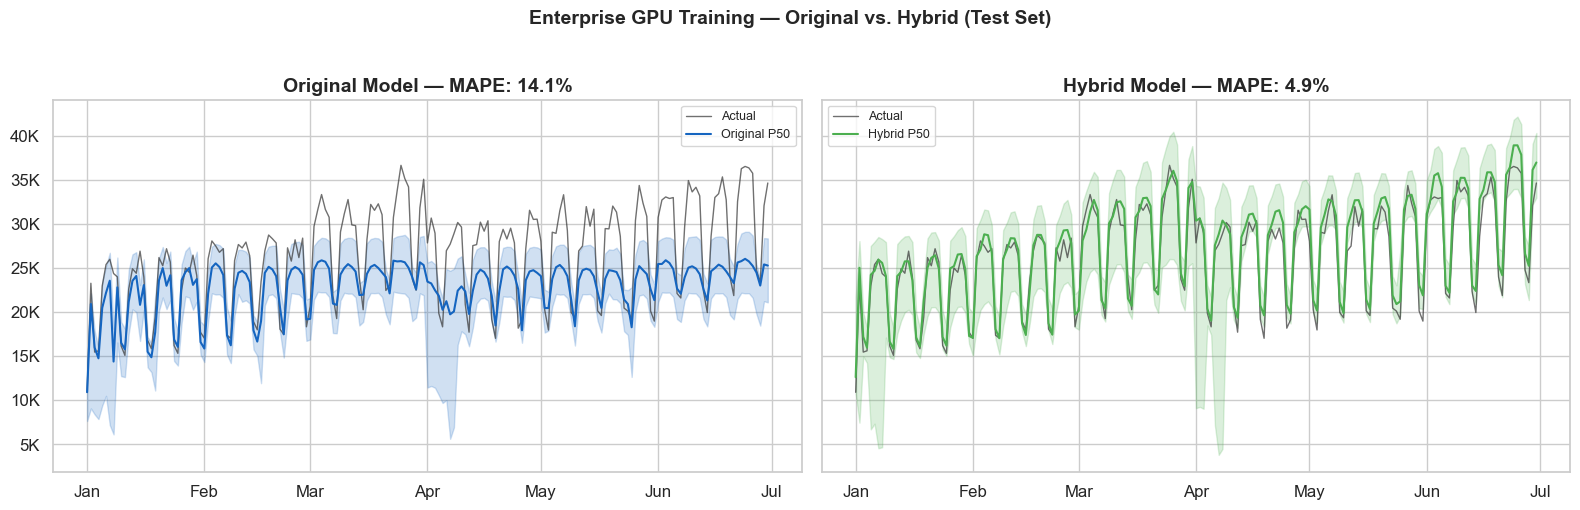

In [34]:
# Visual comparison: Enterprise GPU Training (the target series)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

ctype, seg = "GPU Training", "Enterprise"
mask = ((test["compute_type"] == ctype) & (test["customer_segment"] == seg)).values
dates = test.loc[mask, "date"].values
actual = y_test.values[mask]

# Original model
ax = axes[0]
ax.fill_between(dates, test_preds["P10"][mask], test_preds["P90"][mask], alpha=0.2, color="#1565C0")
ax.plot(dates, actual, color="#333", linewidth=1, alpha=0.7, label="Actual")
ax.plot(dates, test_preds["P50"][mask], color="#1565C0", linewidth=1.5, label="Original P50")
orig_mape = mean_absolute_percentage_error(actual, test_preds["P50"][mask]) * 100
ax.set_title(f"Original Model \u2014 MAPE: {orig_mape:.1f}%", fontweight="bold")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# Hybrid model
ax = axes[1]
ax.fill_between(dates, hybrid_test_p10[mask], hybrid_test_p90[mask], alpha=0.2, color="#4CAF50")
ax.plot(dates, actual, color="#333", linewidth=1, alpha=0.7, label="Actual")
ax.plot(dates, hybrid_test_p50[mask], color="#4CAF50", linewidth=1.5, label="Hybrid P50")
hyb_mape = mean_absolute_percentage_error(actual, hybrid_test_p50[mask]) * 100
ax.set_title(f"Hybrid Model \u2014 MAPE: {hyb_mape:.1f}%", fontweight="bold")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

fig.suptitle(f"Enterprise GPU Training \u2014 Original vs. Hybrid (Test Set)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 11.3 Walk-Forward Backtesting (Hybrid)

Same 3-fold expanding-window validation as the original model, but with the hybrid approach. This confirms the improvement is consistent across time periods, not just the test set.

In [35]:
# Walk-forward backtesting: hybrid model
hybrid_bt_results = []
for fold in folds:
    tr = df[df["date"] <= pd.Timestamp(fold["train_end"])].copy()
    te = df[(df["date"] > pd.Timestamp(fold["train_end"])) & (df["date"] <= pd.Timestamp(fold["test_end"]))].copy()

    # Fit trends on this fold's training data
    fold_trends = fit_series_trends(tr)

    # Compute residual ratios
    tr_ratios = compute_residual_ratios(tr, fold_trends)
    y_tr_log_resid = np.log(tr_ratios)
    te_ratios = compute_residual_ratios(te, fold_trends)
    y_te_log_resid = np.log(te_ratios)

    X_tr, X_te = tr[feature_cols], te[feature_cols]
    y_te_raw = te[TARGET]

    # Train hybrid P50
    m = lgb.LGBMRegressor(**PARAMS)
    m.fit(X_tr, y_tr_log_resid,
          eval_set=[(X_te, y_te_log_resid)],
          callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)],
          categorical_feature=CAT_FEATURES)

    # Reconstruct real-scale predictions
    preds = predict_with_trend(te, m.predict(X_te), fold_trends)
    mape = mean_absolute_percentage_error(y_te_raw, preds) * 100
    mae = mean_absolute_error(y_te_raw, preds)

    # Per-type MAPE
    type_mapes = {}
    for ct in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
        mask = te["compute_type"] == ct
        type_mapes[ct] = mean_absolute_percentage_error(y_te_raw[mask], preds[mask.values]) * 100

    hybrid_bt_results.append({
        "Fold": fold["name"],
        "MAPE": mape,
        "MAE": mae,
        "Best Iter": m.best_iteration_,
        **{f"MAPE_{ct}": v for ct, v in type_mapes.items()},
    })

hybrid_bt_df = pd.DataFrame(hybrid_bt_results)

# Side-by-side comparison
print("Walk-Forward Backtesting \u2014 Original vs. Hybrid:")
print()
print(f"{'Fold':<10} {'Original MAPE':>15} {'Hybrid MAPE':>15} {'Change':>10}")
print("-" * 52)
for i, fold in enumerate(folds):
    orig = bt_df.iloc[i]["MAPE"]
    hyb = hybrid_bt_df.iloc[i]["MAPE"]
    print(f"{fold['name']:<10} {orig:>14.2f}% {hyb:>14.2f}% {hyb-orig:>+9.2f}pp")

print()
print("Per-Type MAPE by Fold (Hybrid):")
for ct in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
    col = f"MAPE_{ct}"
    orig_vals = bt_df[col].values
    hyb_vals = hybrid_bt_df[col].values
    print(f"  {ct}:")
    print(f"    Original: {' / '.join(f'{v:.1f}%' for v in orig_vals)}")
    print(f"    Hybrid:   {' / '.join(f'{v:.1f}%' for v in hyb_vals)}")

Walk-Forward Backtesting — Original vs. Hybrid:

Fold         Original MAPE     Hybrid MAPE     Change
----------------------------------------------------
Fold 1              12.81%          13.22%     +0.40pp
Fold 2               8.40%           7.98%     -0.42pp
Fold 3               7.91%           7.10%     -0.80pp

Per-Type MAPE by Fold (Hybrid):
  GPU Training:
    Original: 18.0% / 10.0% / 8.4%
    Hybrid:   19.5% / 8.9% / 7.7%
  GPU Inference:
    Original: 18.1% / 8.1% / 8.3%
    Hybrid:   19.6% / 7.7% / 7.2%
  CPU Batch:
    Original: 7.6% / 7.6% / 7.4%
    Hybrid:   6.8% / 7.5% / 6.7%
  CPU Interactive:
    Original: 7.5% / 7.8% / 7.5%
    Hybrid:   6.9% / 7.9% / 6.9%


### 11.4 Feature Importance Shift

With the trend removed from the target, the model no longer needs `days_since_start` to approximate growth. Let's see how feature importance shifts \u2014 this validates that the decomposition is working as intended.

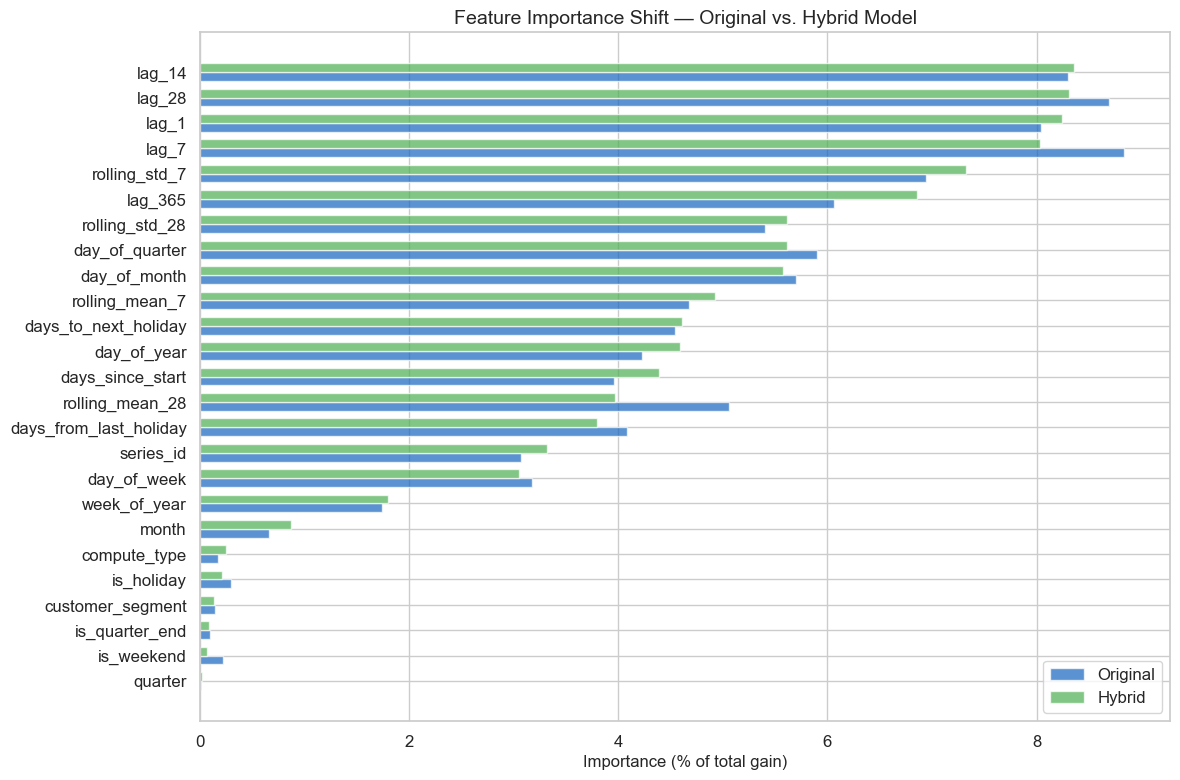

Biggest importance shifts (hybrid - original):
  rolling_mean_28              5.1% →    4.0% ( -1.1pp)
  lag_7                        8.8% →    8.0% ( -0.8pp)
  lag_28                       8.7% →    8.3% ( -0.4pp)
  day_of_quarter               5.9% →    5.6% ( -0.3pp)
  days_from_last_holiday       4.1% →    3.8% ( -0.3pp)
  rolling_mean_7               4.7% →    4.9% ( +0.3pp)
  day_of_year                  4.2% →    4.6% ( +0.4pp)
  rolling_std_7                6.9% →    7.3% ( +0.4pp)
  days_since_start             4.0% →    4.4% ( +0.4pp)
  lag_365                      6.1% →    6.9% ( +0.8pp)


In [36]:
# Compare feature importance: original vs hybrid
orig_imp = pd.DataFrame({
    "feature": feature_cols,
    "original": model_p50.feature_importances_,
})
orig_imp["original_pct"] = orig_imp["original"] / orig_imp["original"].sum() * 100

hybrid_imp = pd.DataFrame({
    "feature": feature_cols,
    "hybrid": hybrid_p50.feature_importances_,
})
hybrid_imp["hybrid_pct"] = hybrid_imp["hybrid"] / hybrid_imp["hybrid"].sum() * 100

imp_compare = orig_imp.merge(hybrid_imp, on="feature")
imp_compare["shift"] = imp_compare["hybrid_pct"] - imp_compare["original_pct"]
imp_compare = imp_compare.sort_values("hybrid_pct", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(imp_compare))
width = 0.35

ax.barh(y_pos + width/2, imp_compare["original_pct"], width, color="#1565C0", alpha=0.7, label="Original")
ax.barh(y_pos - width/2, imp_compare["hybrid_pct"], width, color="#4CAF50", alpha=0.7, label="Hybrid")

ax.set_yticks(y_pos)
ax.set_yticklabels(imp_compare["feature"])
ax.set_xlabel("Importance (% of total gain)")
ax.set_title("Feature Importance Shift \u2014 Original vs. Hybrid Model")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Highlight the biggest shifts
print("Biggest importance shifts (hybrid - original):")
top_shifts = imp_compare.nlargest(5, "shift")[["feature", "original_pct", "hybrid_pct", "shift"]]
bot_shifts = imp_compare.nsmallest(5, "shift")[["feature", "original_pct", "hybrid_pct", "shift"]]
for _, row in pd.concat([top_shifts, bot_shifts]).sort_values("shift").iterrows():
    print(f"  {row['feature']:<25} {row['original_pct']:>6.1f}% \u2192 {row['hybrid_pct']:>6.1f}% ({row['shift']:>+5.1f}pp)")

## 12. Final Model Summary

### Why the Hybrid Model Works

The original LightGBM model predicts absolute demand levels. For fast-growing series like Enterprise GPU Training, test-period values exceed anything in training \u2014 and tree models can't extrapolate. The hybrid approach separates the problem:

| Component | Handled By | Strengths |
|-----------|-----------|-----------|
| **Trend** (growth trajectory) | Per-series exponential regression | Smooth extrapolation beyond training range; parametric, so it naturally extends |
| **Residual** (everything else) | Global LightGBM | Seasonality, holidays, day-of-week, noise \u2014 all stay within a bounded range the model has seen |

The residual target is stationary (centered around 1.0), so LightGBM never needs to predict values outside its training range. The trend handles the extrapolation, and LightGBM handles the pattern recognition.

### Production Recommendation

The hybrid model is the recommended approach for this use case. It addresses the core limitation (extrapolation) without adding significant complexity \u2014 the only addition is a per-series linear regression fit, which is trivial to maintain and retrain.

For the scenario planning notebook (Part 3), the hybrid model's trend + residual decomposition also provides a cleaner interface for scenario adjustments: scale the trend component for growth scenarios, leave the residual model unchanged.

---
*End of Part 2 \u2014 Forecasting Model (Hybrid)*